# Capstone Project - GNN for PPI Tissue Prediction

I am trying to replicate the OhmNet paper but using a Graph Attention Network (GAT) instead of just regular Node2Vec or whatever. It's been really hard to figure out how to handle all these different tissues.

In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch_geometric
from torch_geometric.nn import GATConv
from torch_geometric.data import Data, Batch
from torch_geometric.loader import DataLoader, LinkNeighborLoader
import pandas as pd
import numpy as np
import networkx as nx
import os
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score
import gc
from pronto import Ontology

# Checking if the GPU is active
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device used: {device}")

# Data files location
data_dir = Path('./data')

Device used: cuda


### EDA - Initial File Investigation
I had to look at the folder `data` because I forgot what files were in there and how big they were! I need to know what to do with each one.

In [ ]:
print("Looking at the data files...")
import os
files = os.listdir(data_dir)
for f in files:
    size = os.path.getsize(data_dir / f) / (1024*1024)
    print(f"- {f} ({size:.2f} MB)")

# Visualized the data using basic txt file explorers (showing the files below for reference) and saw a couple of things of interest:
    # - BrendaTissue.obo: This is like a dictionary. I'll read it to map names like 'brain' to IDs like 'BTO:0000142'.
    # - tissue.hierarchy: This has parent-child pairs. I'll build a graph with it for Node2Vec and the custom loss.
    # - PPT-Ohmnet_tissues-combined.edgelist: The main data! 3.6M lines of PPIs. I have to group them by pair then collapse them into a pair-tissues multi-hot vectors

Looking at the data files...
- BrendaTissue.obo (1.74 MB)
- PPT-Ohmnet_tissues-combined.edgelist (78.07 MB)
- tissue.edges (0.01 MB)
- tissue.hierarchy (0.01 MB)


*BTO file*

In [15]:
onto = Ontology(str(data_dir / 'BrendaTissue.obo'))

#Print target tissue ontology
target_ids = ["BTO:0001388", "BTO:0000203"]
for tid in target_ids:
    if tid in onto:
        t = onto[tid]
        print(f"{t.id} -> {t.name}")
    else:
        print(f"{tid} not found in ontology")
target_ids = ["BTO:0001387", "BTO:0000753"]
for tid in target_ids:
    if tid in onto:
        t = onto[tid]
        print(f"{t.id} -> {t.name}")
    else:
        print(f"{tid} not found in ontology")
print("\n")
with open(data_dir / 'BrendaTissue.obo', 'r', encoding='utf-8') as f:
    for i in range(20):
        print(f.readline().strip())

BTO:0001388 -> trachea
BTO:0000203 -> respiratory system
BTO:0001387 -> tonsil
BTO:0000753 -> lymphoid tissue


format-version: 1.2
date: 03:05:2016 09:39
saved-by: Marion, contact@brenda-enzymes.org
auto-generated-by: OBO-Edit 2.3.1
synonymtypedef: GE "LANGUAGE GERMAN"
synonymtypedef: SCI "SCIENTIFIC NAME"
default-namespace: BrendaTissueOBO
remark: www.brenda-enzymes.org

[Term]
id: BTO:0000000
name: tissues, cell types and enzyme sources
def: "A structured controlled vocabulary for the source of an enzyme. It comprises terms of tissues, cell lines, cell types and cell cultures from uni- and multicellular organisms." [curators:mgr]

[Term]
id: BTO:0000001
name: culture condition:-induced cell
is_a: BTO:0000216 ! culture condition

[Term]


*PPI Ohmnet file*

In [16]:
pd.read_csv(data_dir / 'PPT-Ohmnet_tissues-combined.edgelist')

,# protein1\tprotein2\ttissue
0,4790\t79155\turinary_bladder
1,26039\t6597\turinary_bladder
2,57154\t3309\turinary_bladder
3,6631\t9775\turinary_bladder
4,1855\t8312\turinary_bladder
...,...
3666558,6045\t1153\tspermatocyte
3666559,10616\t1387\tspermatocyte
3666560,2033\t7026\tspermatocyte
3666561,324\t1457\tspermatocyte


*tissue.hierarchy*

In [17]:
pd.read_csv(data_dir / 'tissue.hierarchy')

,BTO:0001388\tBTO:0000203_NODE
0,BTO:0001387\tBTO:0000753_NODE
1,BTO:0003099_NODE\tBTO:0000083_NODE
2,BTO:0003092_NODE\tBTO:0003091_NODE
3,BTO:0003091_NODE\tRoot_NODE
4,BTO:0003096_NODE\tBTO:0000082_NODE
...,...
212,BTO:0002295\tBTO:0001515_NODE
213,BTO:0000562\tBTO:0000088_NODE
214,BTO:0000620\tBTO:0000651_NODE
215,BTO:0000199\tBTO:0001369_NODE


### Loading Data
I have to load the tissue hierarchy. I struggled a lot here because I didn't realize it was a directed graph and kept getting the indices mixed up.

In [18]:
# Load the tissue.hierarchy and build directed graph using networkx
tissue_hierarchy_path = data_dir / 'tissue.hierarchy'
G_tissue = nx.read_edgelist(str(tissue_hierarchy_path), create_using=nx.DiGraph())

print(f"The tissue graph has {G_tissue.number_of_nodes()} nodes.")

# Sort list and created indices these because we want the indices to be consistent
tissue_nodes = sorted(list(G_tissue.nodes()))
tissue_to_idx = {node: i for i, node in enumerate(tissue_nodes)}

# Making the edge index for the tissue hierarchy
edges_tissue = []
for u, v in G_tissue.edges():
    edges_tissue.append([tissue_to_idx[u], tissue_to_idx[v]])

# This part was tricky had to read the documentation for shape. I had to transpose it or PyG throws an error.
edges_index_tissue = torch.tensor(edges_tissue, dtype=torch.long).t().contiguous()

print(f"Tissue edge index shape processed: {edges_index_tissue.shape} ") # As per documentation shape has to be ([2, num_edges])

The tissue graph has 219 nodes.
Tissue edge index shape processed: torch.Size([2, 218]) 


### Shape and content debug cell

In [19]:
list(tissue_to_idx)

['BTO:0000000_NODE',
 'BTO:0000041',
 'BTO:0000043',
 'BTO:0000044',
 'BTO:0000045',
 'BTO:0000047_NODE',
 'BTO:0000058_NODE',
 'BTO:0000081_NODE',
 'BTO:0000082_NODE',
 'BTO:0000083_NODE',
 'BTO:0000084',
 'BTO:0000088_NODE',
 'BTO:0000089_NODE',
 'BTO:0000099',
 'BTO:0000123_NODE',
 'BTO:0000125_NODE',
 'BTO:0000128_NODE',
 'BTO:0000129',
 'BTO:0000130',
 'BTO:0000131',
 'BTO:0000132',
 'BTO:0000135',
 'BTO:0000136_NODE',
 'BTO:0000138',
 'BTO:0000140_NODE',
 'BTO:0000141',
 'BTO:0000142_NODE',
 'BTO:0000143',
 'BTO:0000146_NODE',
 'BTO:0000149_NODE',
 'BTO:0000166_NODE',
 'BTO:0000174_NODE',
 'BTO:0000199',
 'BTO:0000202_NODE',
 'BTO:0000203_NODE',
 'BTO:0000206_NODE',
 'BTO:0000211',
 'BTO:0000212',
 'BTO:0000214_NODE',
 'BTO:0000216_NODE',
 'BTO:0000227_NODE',
 'BTO:0000231_NODE',
 'BTO:0000232_NODE',
 'BTO:0000233_NODE',
 'BTO:0000235_NODE',
 'BTO:0000239_NODE',
 'BTO:0000249',
 'BTO:0000267',
 'BTO:0000269',
 'BTO:0000284_NODE',
 'BTO:0000286',
 'BTO:0000292',
 'BTO:0000293_NODE

### Mapping Tissues to BTO IDs
I found out that the PPI file uses names like 'brain' but my hierarchy uses BTO IDs like 'BTO:0000142'. I had to load this BrendaTissue.obo file and match them up manually. I even had to make a 'manual rescue' for tissues with different naming schemes (e.g. b_lymphocyte in PPI is not b lymphocyte but b-lymphocyte in the BTO).

In [20]:
print("Building mapping from BrendaTissue.obo...")
obo_path = data_dir / 'BrendaTissue.obo'
name_to_bto = {}
with open(obo_path, 'r', encoding='utf-8') as f:
    curr_id = None
    for line in f:
        line = line.strip()
        if line.startswith('id: '):
            curr_id = line[4:]
        elif line.startswith('name: ') and curr_id:
            name_to_bto[line[6:].lower()] = curr_id

# I copied this manual rescue because some tissues are just named inconsistently in the data
manual_rescue = {
    'culture condition cd8 cell': 'BTO:0004410',
    'b lymphocyte': 'BTO:0000776',
    'b lymphocytes': 'BTO:0000776', 
    't lymphocyte': 'BTO:0000782', 
    't lymphocytes': 'BTO:0000782'  
}

def get_tissue_idx(t_name):
    # The PPI file uses underscores but names in OBO usually have spaces
    normalized = str(t_name).lower().replace('_', ' ')
    if normalized in manual_rescue:
        bto_id = manual_rescue[normalized]
    else:
        bto_id = name_to_bto.get(normalized)
        
    if not bto_id:
        return None
    
    if bto_id in tissue_to_idx:
        return tissue_to_idx[bto_id]
    if bto_id + '_NODE' in tissue_to_idx:
        return tissue_to_idx[bto_id + '_NODE']
    return None

print(f"Loaded {len(name_to_bto)} names and manual rescues for mapping.")

Building mapping from BrendaTissue.obo...
Loaded 5903 names and manual rescues for mapping.


### Preprocessing PPI Data
Now I have to load the actual protein-protein interactions. I have to map the tissues properly for the multi-hot labeling to work!

In [21]:
# Load the PPI file
ppi_file = data_dir / 'PPT-Ohmnet_tissues-combined.edgelist'
df = pd.read_csv(ppi_file, sep='\t')
df.columns = ['protein_a', 'protein_b', 'tissue']
original_count = len(df)


print("Applying tissue mapping...")
df['t_idx'] = df['tissue'].apply(get_tissue_idx)
df = df.dropna(subset=['t_idx'])
mapped_count = len(df)

print(f"Mapped {mapped_count}/{original_count} PPI records successfully!")

# Getting all unique proteins.
all_proteins = pd.concat([df['protein_a'], df['protein_b']]).unique()
protein_to_idx = {prot: i for i, prot in enumerate(all_proteins)}
num_unique_proteins = len(all_proteins)

print(f"Found {num_unique_proteins} unique proteins.")

Applying tissue mapping...
Mapped 3666563/3666563 PPI records successfully!
Found 4510 unique proteins.


### Handling Labels (Tissues)
Each interaction happens in certain tissues. I need to make a vector where it's 1 if the interaction happens there. I have to group by (protein_a, protein_b) and combine the tissues.

In [22]:
# Grouping by interaction to see which tissues they are in
interaction_groups = df.groupby(['protein_a', 'protein_b'])

# 219
num_tissues = len(tissue_nodes)
# 70338
num_interactions = len(interaction_groups)

# (70338, 219)
labels_matrix = np.zeros((num_interactions, num_tissues))
edge_list_all = []


for i, ((p1, p2), group) in enumerate(interaction_groups):
    u = protein_to_idx[p1]
    v = protein_to_idx[p2]
    edge_list_all.append([u, v])
    
    # Collect all tissues for this pair
    tissues_present_indices = group['t_idx'].unique()
    for tidx in tissues_present_indices:
        labels_matrix[i, int(tidx)] = 1.0

# ([2, 70338]) 
edge_label_index_all = torch.tensor(edge_list_all, dtype=torch.long).t().contiguous()
# ([70338,219])
edge_label_all = torch.tensor(labels_matrix, dtype=torch.float)

print("Grouped unique interactions:", num_interactions)
print("Final Label Matrix Shape:", edge_label_all.shape)

# I need to find the 107 leaf nodes for the final score, needed help
leaf_node_indices = [i for i, node in enumerate(tissue_nodes) if G_tissue.in_degree(node) == 0 and node != 'Root_NODE']
print(f"Found {len(leaf_node_indices)} leaf tissues.")

Grouped unique interactions: 70338
Final Label Matrix Shape: torch.Size([70338, 219])
Found 107 leaf tissues.


### Debugging cell for shape and index check

In [23]:
# Used this cell to gradually debug the above cell using it to see shapes of every element I could
edge_label_all.shape

torch.Size([70338, 219])

### EDA - Visualizing our Labels
Now that I have the labels grouped, I can finally see what the data distribution looks like.

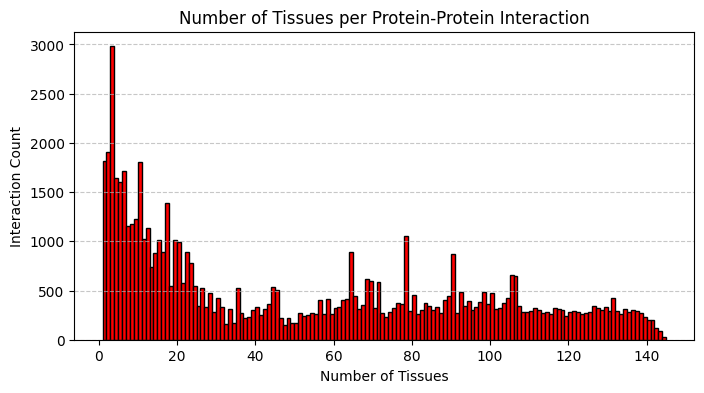

Average tissues per interaction: 52.13


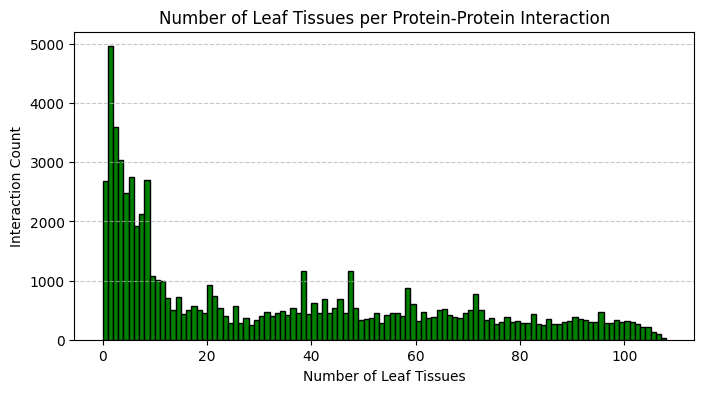

Max leaf tissues for a single interaction: 107.0
Average leaf tissues per interaction: 32.71


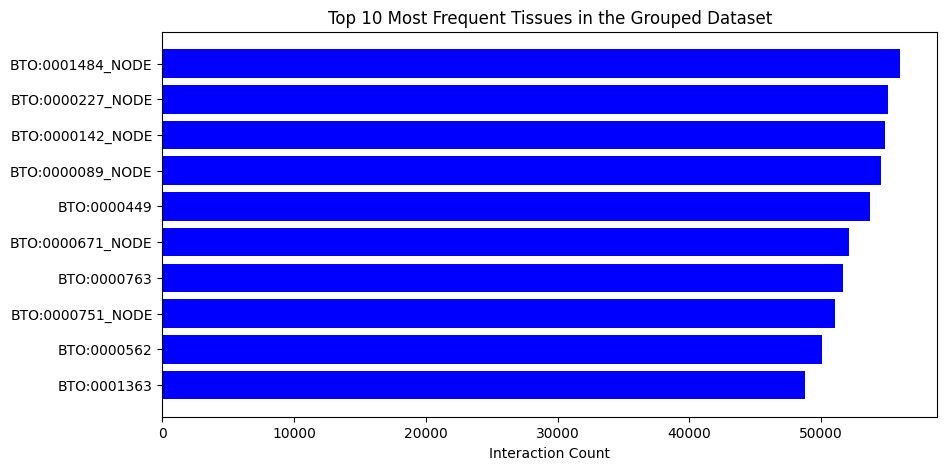

In [24]:
# EDA histogram: How many tissues per interaction?
plt.figure(figsize=(8, 4))
tissues_per_ppi = edge_label_all.sum(dim=1).numpy()
plt.hist(tissues_per_ppi, bins=range(1, int(tissues_per_ppi.max()) + 2), color='r', edgecolor='black')
plt.title("Number of Tissues per Protein-Protein Interaction")
plt.xlabel("Number of Tissues")
plt.ylabel("Interaction Count")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print(f"Average tissues per interaction: {tissues_per_ppi.mean():.2f}")

# EDA histogram: same but only for leaf tissues now (the ones that will be tested later)
# notice the change in scale of number of interactions, everything get skewed to the left which is a good sign for tissue specificity
# edge_label_all shape: [70338, 219]
# leaf_labels_only shape: [70338, 107]
leaf_labels_only = edge_label_all[:, leaf_node_indices]
# Now sum sideways across the 107 leaf tissues
leaf_tissues_per_ppi = leaf_labels_only.sum(dim=1).numpy()
plt.figure(figsize=(8, 4))
# Note: we use bins starting from 0 in case some PPIs have no leaf-level annotations
plt.hist(leaf_tissues_per_ppi, bins=range(0, int(leaf_tissues_per_ppi.max()) + 2), color='g', edgecolor='black')
plt.title("Number of Leaf Tissues per Protein-Protein Interaction")
plt.xlabel("Number of Leaf Tissues")
plt.ylabel("Interaction Count")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
print(f"Max leaf tissues for a single interaction: {leaf_tissues_per_ppi.max()}")
print(f"Average leaf tissues per interaction: {leaf_tissues_per_ppi.mean():.2f}")

# EDA barh: Top 10 Most Common Tissues?
plt.figure(figsize=(10, 5))
tissue_counts = edge_label_all.sum(dim=0).numpy()
top_indices = np.argsort(tissue_counts)[-10:]
plt.barh([tissue_nodes[i] for i in top_indices], tissue_counts[top_indices], color='b')
plt.title("Top 10 Most Frequent Tissues in the Grouped Dataset")
plt.xlabel("Interaction Count")
plt.show()

### Splitting the data
I need to divide this into train, validation, and test. The expert said to do an 80/20 split then split the 80% again to get the 72/8/20 ratio.

In [25]:
from sklearn.model_selection import train_test_split

# I experimented with train/val/test as 80/10/10 vs the current 72/8/20 and the results were comparable for the same hyperparameters.
# I was getting test AUROC of 0.97xx-0.98xx depending on the training run and early stopping triggered between 870-940 epochs
indices = np.arange(num_interactions)
# First split: 20% for testing
train_val_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=42, shuffle=True)
# Second split: 10% of the remaining for validation (which is 8% of total)
train_idx, val_idx = train_test_split(train_val_idx, test_size=0.1, random_state=42)

print(f"Train size: {len(train_idx)}, Val size: {len(val_idx)}, Test size: {len(test_idx)}")

full_graph_data = Data(x=torch.arange(num_unique_proteins), edge_index=edge_label_index_all)

# Increased batch size this so it trains faster and we have room on GPU (only about 10GB used during training according to my monitoring).
# Also tried with batch size of 4k and it led to having only 12 updates per epoch which wasn't great for faster convergence
batch_size = 1024 

# As mentioned in the project proposal, using neighbor sampling
train_loader = LinkNeighborLoader(
    full_graph_data,
    # 2 GATconv so 2 hops: 15 random neighbors sampled for each protein in the pair then these random neighbors select another 10 random neighbors
    # In total, 2 + 2*15 + 2*15*10 proteins are sampled each step with a batch size of 1024, that's about 340k proteins/neighborhoods per batch
    # the alternative to neighbor_loader is the entire graph which I tried with a low batch size and it was using 54GB of VRAM so I went OOM
    num_neighbors=[15, 10], 
    batch_size=batch_size,
    edge_label_index=edge_label_index_all[:, train_idx],
    edge_label=edge_label_all[train_idx],
    shuffle=True
)

val_loader = LinkNeighborLoader(
    full_graph_data,
    num_neighbors=[15, 10],
    batch_size=batch_size,
    edge_label_index=edge_label_index_all[:, val_idx],
    edge_label=edge_label_all[val_idx],
    shuffle=False
)

test_loader = LinkNeighborLoader(
    full_graph_data,
    num_neighbors=[15, 10],
    batch_size=batch_size,
    edge_label_index=edge_label_index_all[:, test_idx],
    edge_label=edge_label_all[test_idx],
    shuffle=False
)

Train size: 50643, Val size: 5627, Test size: 14068


### Data leakage check

In [39]:
# Check if there is any overlap between sets
train_set = set(train_idx)
val_set = set(val_idx)
test_set = set(test_idx)

assert train_set.isdisjoint(val_set), "Leakage: Overlap between Train and Val"
assert train_set.isdisjoint(test_set), "Leakage: Overlap between Train and Test"
assert val_set.isdisjoint(test_set), "Leakage: Overlap between Val and Test"
print("Sets are perfectly disjoint. No label leakage.")

Sets are perfectly disjoint. No label leakage.


### Tissue Embeddings (Node2Vec)
Using Node2Vec to get features for the tissues.

In [ ]:
from torch_geometric.nn import Node2Vec

# embedding_dim at 256d is slightly better than at 64 and 128d perhaps because we are working with 218 edges so 256 offers a bit more "mathematical space"
# but the difference is marginal, losses went from about 0.76xx to 0.7456 so slightly better
tissue_n2v_model = Node2Vec(edges_index_tissue, embedding_dim=256, walk_length=20, 
                            context_size=10, walks_per_node=10, num_negative_samples=1, 
                            sparse=True).to(device)

# glorot init chosen after observing astronimical losses and slow convergence (l=4.7), glorot used because it was used in the GAT paper but I didn't try other methods
# I am aware we are not training a GAT here but I still chose Xavier Glorot normal init because it's the first that came to mind after reading the paper
torch.nn.init.xavier_uniform_(tissue_n2v_model.embedding.weight)

n2v_loader = tissue_n2v_model.loader(batch_size=128, shuffle=True, num_workers=0)
n2v_optimizer = torch.optim.SparseAdam(list(tissue_n2v_model.parameters()), lr=0.01)

tissue_n2v_model.train()
for epoch in range(1, 1001):
    total_loss = 0
    for pos_rw, neg_rw in n2v_loader:
        n2v_optimizer.zero_grad()
        loss = tissue_n2v_model.loss(pos_rw.to(device), neg_rw.to(device))
        loss.backward()
        n2v_optimizer.step()
        total_loss += loss.item()
    if epoch % 100 == 0:
        print(f"Node2Vec Epoch {epoch}, Loss: {total_loss/len(n2v_loader):.4f}")

global_tissue_address = tissue_n2v_model().detach()
print("Tissue embeddings ready.")

Node2Vec Epoch 100, Loss: 0.7699
Node2Vec Epoch 200, Loss: 0.7582
Node2Vec Epoch 300, Loss: 0.7551
Node2Vec Epoch 400, Loss: 0.7534
Node2Vec Epoch 500, Loss: 0.7468
Node2Vec Epoch 600, Loss: 0.7488
Node2Vec Epoch 700, Loss: 0.7478
Node2Vec Epoch 800, Loss: 0.7487
Node2Vec Epoch 900, Loss: 0.7461
Node2Vec Epoch 1000, Loss: 0.7456
Tissue embeddings ready.


### Visualizing the tissue hierarchy

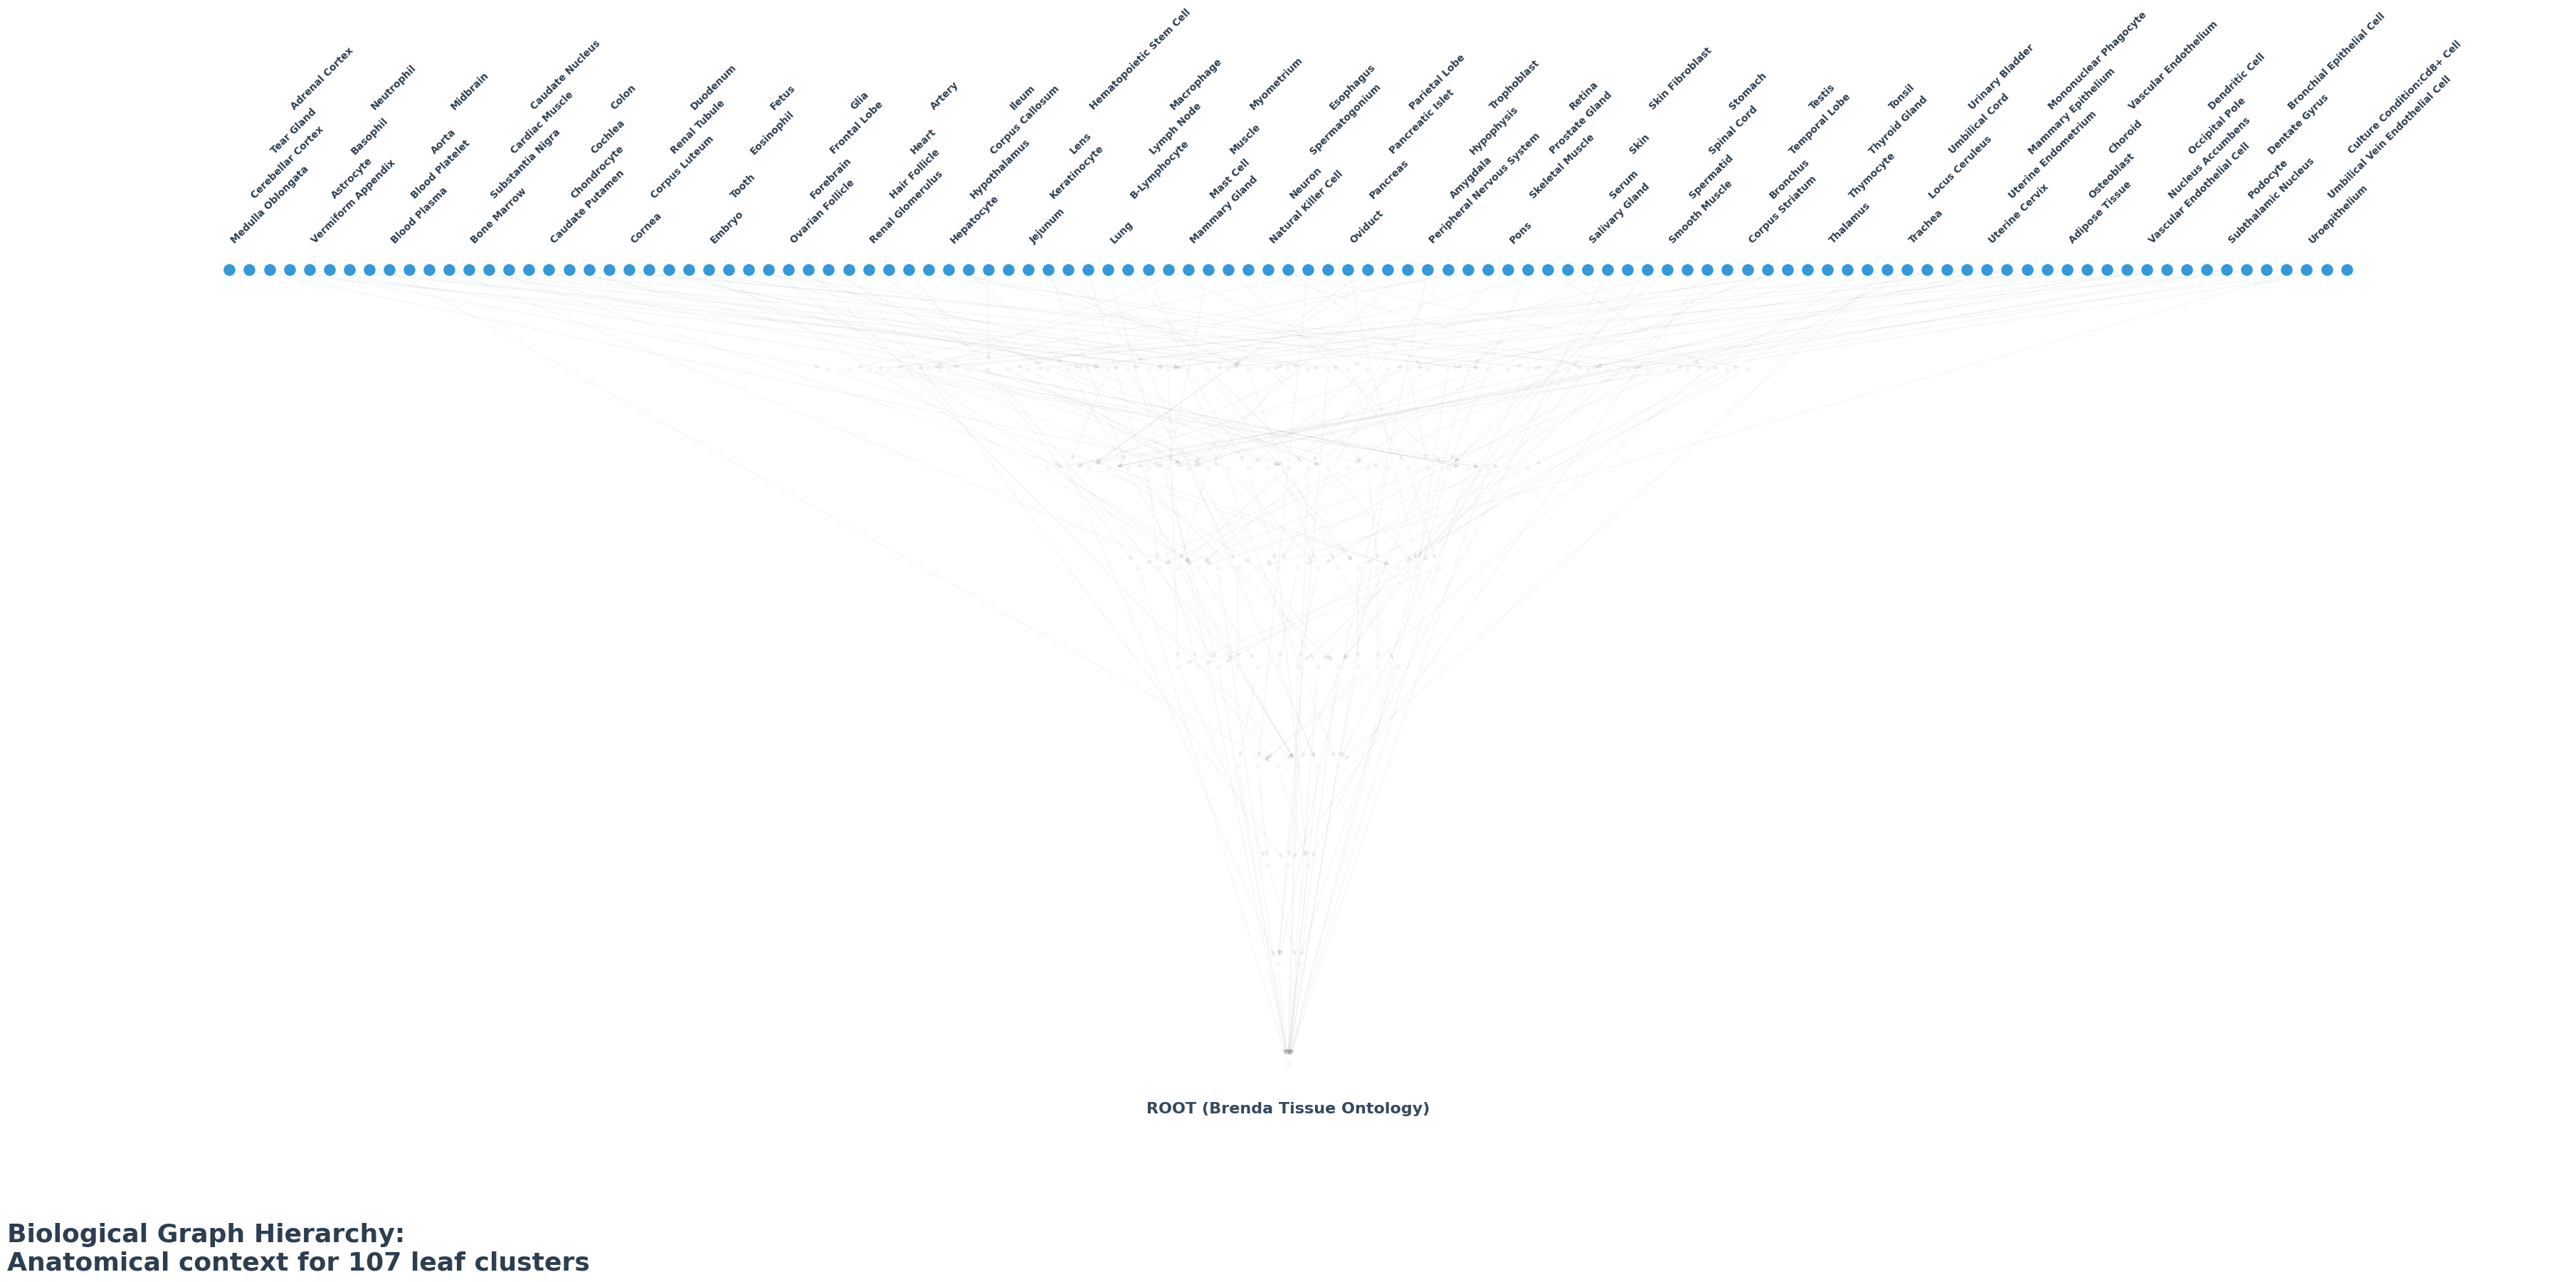

In [53]:
# This is an extra, I did not code this, do not credit me for it
# 1. Reverse Mapping
bto_to_name = {v: k.title() for k, v in name_to_bto.items()}
# 2. Setup Node metadata
leaf_tissues = sorted([n for n in G_tissue.nodes() if G_tissue.in_degree(n) == 0])
root_node = 'Root_NODE'
# 3. Enhanced Pos Map (Huge horizontal scaling)
generations = list(nx.topological_generations(G_tissue))
pos = {}
for y, nodes in enumerate(generations):
    nodes = sorted(nodes)
    layer_width = len(nodes)
    for x, node in enumerate(nodes):
        pos[node] = (x * 6.5 - (layer_width * 6.5 - 1) / 2, -y)
# 4. Ultra-wide High-Res Canvas
fig = plt.figure(figsize=(40, 18))
# 5. Draw connections and background nodes
nx.draw_networkx_edges(G_tissue, pos, alpha=0.08, edge_color='#7f8c8d', arrows=True, arrowsize=10)
nx.draw_networkx_nodes(G_tissue, pos, nodelist=[n for n in G_tissue.nodes() if n not in leaf_tissues], 
                       node_size=20, node_color='#ecf0f1', alpha=0.4)
# 6. Draw Prediction Targets (The 107 Leaf Tissues)
nx.draw_networkx_nodes(G_tissue, pos, nodelist=leaf_tissues, 
                       node_size=180, node_color='#3498db', edgecolors='white', linewidths=1.5)
# 7. Labels with 4-Level Staggering and 45-degree rotation
for i, node in enumerate(leaf_tissues):
    x, y = pos[node]
    clean_id = node.replace('_NODE', '')
    name = bto_to_name.get(clean_id, clean_id)
    
    # Cycles through 4 heights to prevent horizontal text collisions
    height_offset = [0.25, 0.7, 1.15, 1.6][i % 4]
    
    plt.text(x, y + height_offset, name, 
             rotation=45, fontsize=10, fontweight='bold',
             ha='left', va='bottom', color='#2c3e50',
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=1))
# 8. Label the Root at the bottom-center
root_x, root_y = pos[root_node]
plt.text(root_x, root_y - 0.5, "ROOT (Brenda Tissue Ontology)", 
         fontsize=16, fontweight='extra bold', ha='center', color='#34495e')
# 9. Position Title in the Bottom Left Corner
plt.figtext(0.05, 0.05, "Biological Graph Hierarchy:\nAnatomical context for 107 leaf clusters", 
            fontsize=26, fontweight='bold', color='#2c3e50', 
            ha='left', va='bottom')
plt.axis('off')
plt.subplots_adjust(top=0.9, bottom=0.15, left=0.05, right=0.95)
plt.show()

### Defining the Model
Late Fusion GAT model.

In [ ]:
# Needed help to define this, some parts were easy like self.gat1 and self.gat2 and self.mlp but defining the forward method was harder
class LateFusionGAT(nn.Module):
    def __init__(self, num_proteins, protein_embedding_dim, num_heads, gat_hidden_channels, 
                 gat_output_channels, tissue_address_dim, mlp_hidden_channels, 
                 num_tissues, global_tissue_address_tensor, dropout_rate=0.5):
        super().__init__()
        self.num_tissues = num_tissues
        self.global_tissue_address = nn.Parameter(global_tissue_address_tensor, requires_grad=False)
        self.protein_embedding = nn.Embedding(num_proteins, protein_embedding_dim)
        
        self.gat1 = GATConv(protein_embedding_dim, gat_hidden_channels, heads=num_heads, dropout=dropout_rate)
        self.gat2 = GATConv(gat_hidden_channels * num_heads, gat_output_channels, heads=1, concat=False, dropout=dropout_rate)
        
        combined_dim = gat_output_channels * 2 + tissue_address_dim
        self.mlp = nn.Sequential(
            nn.Linear(combined_dim, mlp_hidden_channels),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(mlp_hidden_channels, 1)
        )

    def forward(self, batch):
        x = self.protein_embedding(batch.x.to(device))
        x = F.elu(self.gat1(x, batch.edge_index.to(device))) # elu used in the original paper
        x = self.gat2(x, batch.edge_index.to(device))
        
        u_idx, v_idx = batch.edge_label_index[0], batch.edge_label_index[1]
        u_feat, v_feat = x[u_idx], x[v_idx]
        
        # complex dimensionality, difficult to understand, needed help to figure this part out
        batch_size = u_feat.size(0)
        u_feat_expanded = u_feat.unsqueeze(1).repeat(1, self.num_tissues, 1)
        v_feat_expanded = v_feat.unsqueeze(1).repeat(1, self.num_tissues, 1)
        tissue_feat = self.global_tissue_address.unsqueeze(0).repeat(batch_size, 1, 1)
        
        combined = torch.cat([u_feat_expanded, v_feat_expanded, tissue_feat], dim=-1)
        out = self.mlp(combined).squeeze(-1)
        return torch.sigmoid(out)

### Custom Loss Function
Adding a penalty for hierarchy violations.

In [28]:
hierarchical_pairs = edges_index_tissue.t()

# Needed help to define the new loss function but didn't realize it was simpler than I thought
def custom_loss(predictions, targets, hierarchy_edges, lambda_penalty=0.1):
    bce = F.binary_cross_entropy(predictions, targets)
    child_idx, parent_idx = hierarchy_edges[:, 0], hierarchy_edges[:, 1]
    
    # Predictions for children should be <= predictions for parents
    diff = predictions[:, child_idx] - predictions[:, parent_idx]
    # clamp() returns a value within the defined min/max, here we define a min but no max. The penalty is squared to penalize more heavily
    # a hierarchy violation but it could've been done through the lambda_penalty. It worked well as is.
    penalty = torch.mean(torch.clamp(diff, min=0)**2) 
    return bce + lambda_penalty * penalty

In [29]:
hierarchical_pairs

tensor([[172,  34],
        [ 34, 218],
        [171, 106],
        [106, 218],
        [211,   9],
        [  9,   7],
        [209, 208],
        [208, 218],
        [210,   8],
        [  8,   7],
        [ 88, 126],
        [126, 218],
        [195,  70],
        [ 70,  33],
        [117,  68],
        [ 68, 218],
        [194,  94],
        [ 94,  76],
        [160, 106],
        [116,  29],
        [ 29, 167],
        [ 40, 185],
        [185, 218],
        [196,  67],
        [ 67,  22],
        [139, 211],
        [140,  16],
        [ 16, 191],
        [138,  42],
        [ 42, 100],
        [192,  65],
        [ 65,  93],
        [ 33, 218],
        [ 35, 187],
        [187, 218],
        [200, 121],
        [121, 183],
        [201,  52],
        [ 52,  71],
        [ 72,  31],
        [ 31,  49],
        [ 71,  43],
        [ 43,  45],
        [  6, 190],
        [190, 218],
        [142, 218],
        [143, 106],
        [183,  26],
        [120,  86],
        [ 86,  84],


### THE TRAINING LOOP
Model structural hyperparameters and model instantiation separated from the training loop to load the model later.

In [ ]:
# These are the parameters I determined were optimal
protein_embedding_dim = 256
num_heads = 16
gat_hidden_channels = 256 # I started with 128 then went to 256 and observed an improvement in metrics, same for gat_output_channels
gat_output_channels = 256
tissue_address_dim = global_tissue_address.shape[1]
mlp_hidden_channels = 1024
# In the original GAT paper, they used a dropout value of 0.4 (at that time and in the original dropout paper, p was the prob of being kept)
# I started with 0.3 then went to 0.4 and to 0.5 and observed a consistent decline in metrics (lower AUROC, AUPRN and Macro-F1), as well as higher losses
# After this hyperparameter search, I settled on 0.3
dropout_rate = 0.3

model = LateFusionGAT(
    num_proteins=num_unique_proteins, protein_embedding_dim=protein_embedding_dim,
    num_heads=num_heads, gat_hidden_channels=gat_hidden_channels,
    gat_output_channels=gat_output_channels, tissue_address_dim=tissue_address_dim,
    mlp_hidden_channels=mlp_hidden_channels, num_tissues=num_tissues,
    global_tissue_address_tensor=global_tissue_address, dropout_rate=dropout_rate
).to(device)

Training with early stopping.

In [ ]:
#fairly standard training loop with early stopping
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
num_epochs = 1000
patience = 50
best_val_loss = float('inf')
epochs_no_improve = 0
history = {'train': [], 'val': []}

for epoch in range(num_epochs):
    model.train()
    total_train_loss = 0
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        preds = model(batch)
        loss = custom_loss(preds, batch.edge_label, hierarchical_pairs.to(device))
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()
        
    avg_train_loss = total_train_loss / len(train_loader)
    history['train'].append(avg_train_loss)
    
    model.eval()
    total_val_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)
            preds = model(batch)
            loss = custom_loss(preds, batch.edge_label, hierarchical_pairs.to(device))
            total_val_loss += loss.item()
    
    avg_val_loss = total_val_loss / len(val_loader)
    history['val'].append(avg_val_loss)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}, Train: {avg_train_loss:.4f}, Val: {avg_val_loss:.4f}")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), 'best_model.pt')
    else:
        epochs_no_improve += 1
    
    if epochs_no_improve >= patience:
        print(f"Early stopping at {epoch+1}!")
        break

Epoch 10, Train: 0.3268, Val: 0.3128
Epoch 20, Train: 0.2933, Val: 0.2694
Epoch 30, Train: 0.2749, Val: 0.2519
Epoch 40, Train: 0.2609, Val: 0.2314
Epoch 50, Train: 0.2489, Val: 0.2186
Epoch 60, Train: 0.2434, Val: 0.2105
Epoch 70, Train: 0.2381, Val: 0.2044
Epoch 80, Train: 0.2299, Val: 0.1950
Epoch 90, Train: 0.2229, Val: 0.1923
Epoch 100, Train: 0.2202, Val: 0.1868
Epoch 110, Train: 0.2175, Val: 0.1800
Epoch 120, Train: 0.2134, Val: 0.1801
Epoch 130, Train: 0.2098, Val: 0.1774
Epoch 140, Train: 0.2078, Val: 0.1737
Epoch 150, Train: 0.2039, Val: 0.1684
Epoch 160, Train: 0.2030, Val: 0.1670
Epoch 170, Train: 0.1988, Val: 0.1640
Epoch 180, Train: 0.1963, Val: 0.1624
Epoch 190, Train: 0.1930, Val: 0.1596
Epoch 200, Train: 0.1915, Val: 0.1583
Epoch 210, Train: 0.1910, Val: 0.1564
Epoch 220, Train: 0.1881, Val: 0.1544
Epoch 230, Train: 0.1870, Val: 0.1516
Epoch 240, Train: 0.1839, Val: 0.1487
Epoch 250, Train: 0.1852, Val: 0.1467
Epoch 260, Train: 0.1814, Val: 0.1458
Epoch 270, Train: 0.1

### PLotting loss curves

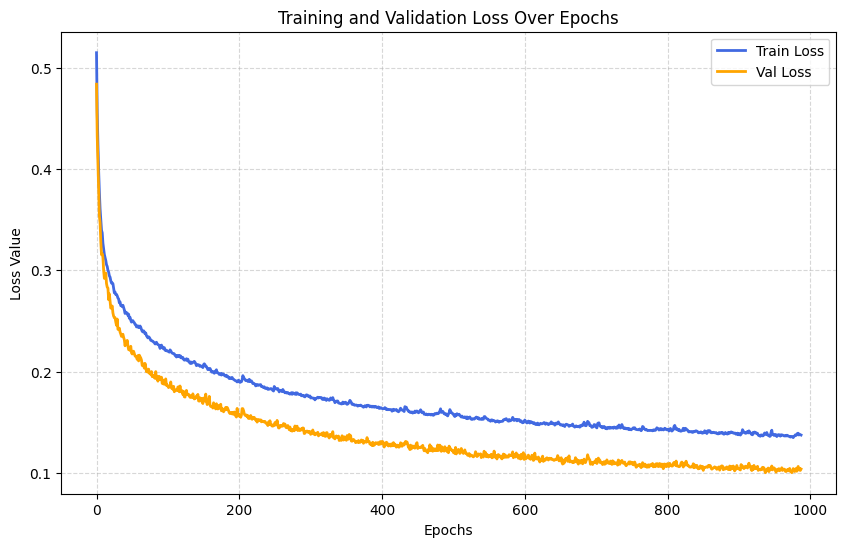

In [ ]:
# I wanted to see the learning curve of the model, val losses consistently under train losses because of dropout I believe, I've seen this training CNNs in other class
plt.figure(figsize=(10, 6))
plt.plot(history['train'], label='Train Loss', color='royalblue', linewidth=2)
plt.plot(history['val'], label='Val Loss', color='orange', linewidth=2)

plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss Value')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()


### Load model

In [33]:
# I saved the weights during training whenever the validation loss got better.
# Now I'm loading them back so I can test the 'best' version of the model.
model_path = 'best_model.pt'

if os.path.exists(model_path):
    print(f"Loading weights from {model_path}...")
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()
    print("Model loaded and ready for testing!")
else:
    print(f"Error: Could not find {model_path}. Did the training finish?")


Loading weights from best_model.pt...
Model loaded and ready for testing!


C:\Users\steve\AppData\Local\Temp\ipykernel_29088\468446361.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=dev

### Testing Results

In [34]:
from sklearn.metrics import average_precision_score, f1_score

model.eval()
all_preds, all_labels = [], []
leaf_auprc = []
leaf_f1_scores = []

threshold = 0.5

print(f"Calculating metrics for {len(leaf_node_indices)} leaf tissues...")

with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        preds = model(batch)
        all_preds.append(preds.cpu())
        all_labels.append(batch.edge_label.cpu())

all_preds = torch.cat(all_preds, dim=0).numpy()
all_labels = torch.cat(all_labels, dim=0).numpy()

leaf_auroc = []
for j in leaf_node_indices:
    if all_labels[:, j].sum() > 0 and (1.0 - all_labels[:, j]).sum() > 0:
        leaf_auroc.append(roc_auc_score(all_labels[:, j], all_preds[:, j]))


for j in leaf_node_indices:
    # Get the true labels and my model's predictions for this specific tissue
    y_true = all_labels[:, j]
    y_pred = all_preds[:, j]
    
    # I can only calculate scores if there is at least one '1' and one '0' in the test set
    if y_true.sum() > 0 and (1.0 - y_true).sum() > 0:
        # AUPRC (Average Precision)
        auprc = average_precision_score(y_true, y_pred)
        leaf_auprc.append(auprc)
        
        # F1 Score (requires turning probabilities into 0 or 1)
        y_pred_binary = (y_pred >= threshold).astype(int)
        f1 = f1_score(y_true, y_pred_binary, zero_division=0)
        leaf_f1_scores.append(f1)
        
# Now I average them to get the 'Macro' results
print(f"--- Leaf Tissue Results ---")
print(f"Test Leaf AUROC: {np.mean(leaf_auroc):.4f}")
print(f"Macro-AUPRC: {np.mean(leaf_auprc):.4f}")
print(f"Macro-F1 Score: {np.mean(leaf_f1_scores):.4f}")
if np.mean(leaf_auroc) > 0.756:
    print(f"Based on test AUROC score, the project was a success for achieving an AUROC score significantly higher than 0.756!")
print(f"(Based on {len(leaf_auprc)} tissues that had valid test data)")

Calculating metrics for 107 leaf tissues...
--- Leaf Tissue Results ---
Test Leaf AUROC: 0.9775
Macro-AUPRC: 0.9041
Macro-F1 Score: 0.8403
Based on test AUROC score, the project was a success for achieving an AUROC score significantly higher than 0.756!
(Based on 107 tissues that had valid test data)


### Hub protein analysis

In [37]:
# Identify the hub protein (the one with the most interactions in column 'protein_a')
hub_protein = df['protein_a'].value_counts().idxmax()
# Filter for all unique pairs involving the hub protein
# We drop duplicates because the same interaction can appear multiple times if it occurs in multiple tissues
unique_pairs = df[['protein_a', 'protein_b']].drop_duplicates()
# Find neighbors where hub is protein_a
neighbors_from_a = unique_pairs[unique_pairs['protein_a'] == hub_protein]['protein_b']
# Find neighbors where hub is protein_b
neighbors_from_b = unique_pairs[unique_pairs['protein_b'] == hub_protein]['protein_a']
# Combine both and get the count of unique IDs
total_neighbors = pd.concat([neighbors_from_a, neighbors_from_b]).unique()
print(f"Hub Protein {hub_protein} has {len(total_neighbors)} unique neighbors.")

Hub Protein 1956 has 458 unique neighbors.


### Attention weights

In [35]:
# Identify the hub protein
target_prot = df['protein_a'].value_counts().idxmax()
target_idx = protein_to_idx[target_prot]

# Get a list of all protein names based on their indices
idx_to_protein = {v: k for k, v in protein_to_idx.items()}

model.eval()
with torch.no_grad():
    # 1. Get embeddings and attention weights from the first GAT layer
    x_emb = model.protein_embedding(full_graph_data.x.to(device))
    _, (edge_idx, alpha) = model.gat1(x_emb, full_graph_data.edge_index.to(device), return_attention_weights=True)
    
    # 2. Average weights across all heads and move to CPU
    alpha = alpha.mean(dim=-1).cpu().numpy()
    edge_idx = edge_idx.cpu().numpy()
    
    # 3. Filter for edges connected to our target protein
    mask = (edge_idx[0] == target_idx)
    neighbor_indices = edge_idx[1, mask]
    neighbor_weights = alpha[mask]
    
    # 4. Sort neighbors by attention weight (highest first)
    sorted_indices = np.argsort(neighbor_weights)[::-1]
    
    print(f"Top 10 Attention Weights for Protein: {target_prot}")
    print("-" * 45)
    print(f"{'Neighbor Protein':<20} | {'Attention Weight':<15}")
    print("-" * 45)
    
    for i in range(min(10, len(sorted_indices))):
        idx = sorted_indices[i]
        neighbor_name = idx_to_protein[neighbor_indices[idx]]
        weight = neighbor_weights[idx]
        print(f"{neighbor_name:<20} | {weight:.4f}")


Top 10 Attention Weights for Protein: 1956
---------------------------------------------
Neighbor Protein     | Attention Weight
---------------------------------------------
4257                 | 0.3095
3226                 | 0.2617
10439                | 0.2096
26270                | 0.1938
6523                 | 0.1770
84174                | 0.1661
7389                 | 0.1494
1490                 | 0.1464
1299                 | 0.1314
3371                 | 0.1300


### Plotting attention weights

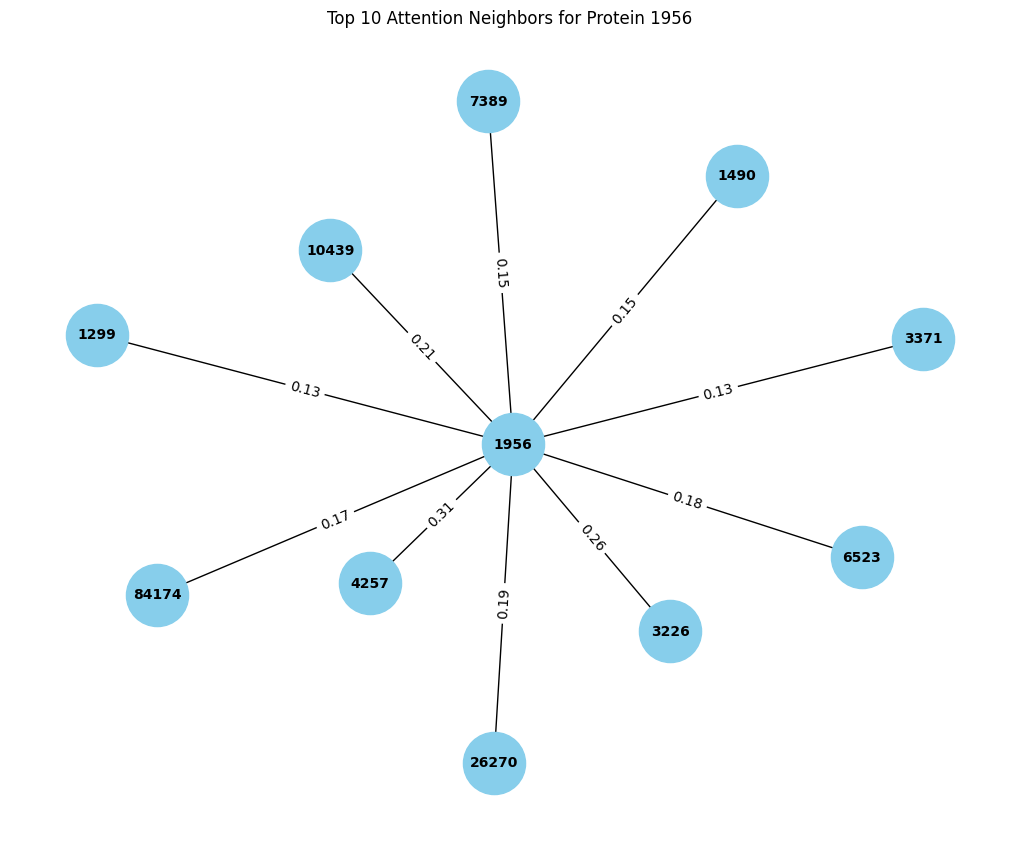

In [38]:
def simple_plot_attn(target_prot):
    target_idx = protein_to_idx[target_prot]
    
    # Map index back to name for graph labels
    idx_to_protein = {v: k for k, v in protein_to_idx.items()}
    
    model.eval()
    with torch.no_grad():
        x_emb = model.protein_embedding(full_graph_data.x.to(device))
        _, (edge_idx, alpha) = model.gat1(x_emb, full_graph_data.edge_index.to(device), return_attention_weights=True)
        
        alpha = alpha.mean(dim=-1).cpu().numpy()
        edge_idx = edge_idx.cpu().numpy()
        
        # Filter for neighbors where our protein is the source (edge_idx[0])
        mask = (edge_idx[0] == target_idx)
        sub_edges = edge_idx[:, mask]
        sub_alpha = alpha[mask]
        
        # --- NEW: Sort by attention weight descending ---
        sort_idx = np.argsort(sub_alpha)[::-1]
        top_idx = sort_idx[:10]  # Take the top 10
        
        G = nx.Graph()
        for i in top_idx:
            u_name = idx_to_protein[sub_edges[0, i]]
            v_name = idx_to_protein[sub_edges[1, i]]
            G.add_edge(u_name, v_name, weight=sub_alpha[i])
            
        plt.figure(figsize=(10, 8))
        pos = nx.spring_layout(G)
        nx.draw(G, pos, with_labels=True, node_size=2000, node_color='skyblue', font_size=10, font_weight='bold')
        
        # Add labels for the weights on the edges
        edge_labels = {(u, v): f"{d['weight']:.2f}" for u, v, d in G.edges(data=True)}
        nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
        
        plt.title(f"Top 10 Attention Neighbors for Protein {target_prot}")
        plt.show()

# Call the fixed function
simple_plot_attn(hub_protein)